# 1. Scope: where does a name get its value?

Learn to distinguish local, enclosing, global, and built-in names, recognize hidden dependencies, and pass preprocessing settings explicitly. Prerequisite: [Functions and parameters](../../../01_Python_Foundations/06_functions_and_parameters.ipynb). Allow two hours, including tracing which value each function reads. This lesson explains programming state and a small preprocessing example; it does not train a predictive model.

## 2. What problem does this solve?

A function may produce different results even when its visible arguments do not change. One reason is that it reads a global variable modified elsewhere in the notebook. If a cell changes a scaling mean or decision threshold, earlier function definitions can silently start using the new value.

Scope rules explain where Python finds a name. Understanding them helps prevent hidden state, accidental configuration changes, and confusing errors. For ML, a preprocessing statistic estimated from training data should remain the same when transforming held-out examples. Its origin and use must be visible.

## 3. Intuition and analogy

Imagine a workplace with a note on your own desk, a note in the room containing your desk, a shared office noticeboard, and an official reference manual. A name is resolved by looking in increasingly broader places. Two notes can have the same title while containing different values.

The narrower note can hide the broader one. This is called shadowing. It can be intentional, such as using an argument named `value`, or accidental, such as naming a variable `sum` and hiding Python's built-in addition helper. A visible label is not enough; ask which location supplies its meaning.

## 4. Terminology

**Local scope** contains names belonging to one function call. **Enclosing scope** belongs to an outer function around a nested function. **Global scope** is the module-level namespace, including top-level notebook assignments. **Built-ins** include standard names such as `len`, `sum`, and `ValueError`.

The common lookup mnemonic is **LEGB**: local, enclosing, global, built-in. A **namespace** associates names with objects. A **closure** is a function retaining access to names from an enclosing function. **Shadowing** gives a narrower name precedence over a broader one. `global` and `nonlocal` change where assignments are directed; they should be used deliberately rather than as a first response to confusing state.

## 5. Mathematical foundations

Centering subtracts a reference mean from a measurement:

$$z=x-\mu_{train},\qquad \mu_{train}=\frac{1}{n}\sum_{i=1}^{n}x_i.$$

x is one new measurement, $x_i$ are the n training measurements, and $\mu_{train}$ is their mean. z is a deviation from the training mean, with the same units as x. Each quantity here is a scalar. A collection of n measurements would produce a length-n collection of deviations.

The subscript train records an information constraint: the mean comes from training observations. Changing it using held-out observations changes the transformation and contaminates an experiment intended to apply a fixed trained procedure.

## 6. Hand-calculated example

Training values one and three have mean $(1+3)/2=2$. A new value of 100 transforms to $100-2=98$. If an exploratory cell replaces the reference with the new sample's mean, 100, the result becomes zero. Both subtractions are arithmetically valid, but only the first follows the declared training-only protocol.

This example deliberately exaggerates the shift to make the mechanism visible. It does not establish a useful model or realistic distribution. Its purpose is to show how hidden configuration can change an otherwise identical function call.

## 7. Implementation with a visible hidden dependency

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
reference_mean = 2.0

def center_hidden(value):
    return value - reference_mean

first_result = center_hidden(100.0)
reference_mean = 100.0
second_result = center_hidden(100.0)
print('Same visible argument; different global reference:', first_result, second_result)
assert first_result == 98 and second_result == 0

Same visible argument; different global reference: 98.0 0.0


The function looks up the global name when called. Defining the function while the value was two did not freeze that global value. The demonstration is intentionally problematic; the next version makes the dependency explicit.

## 8. Step-by-step scope inspection

In [3]:
reference_mean = 2.0

def center_explicit(value, mean):
    centered = value - mean
    return centered

explicit_result = center_explicit(100.0, mean=reference_mean)
reference_mean = 100.0
assert center_explicit(100.0, mean=2.0) == explicit_result == 98
assert 'centered' not in globals()
print('Explicit training reference gives:', explicit_result)

Explicit training reference gives: 98.0


`value`, `mean`, and `centered` are local names during each call. The caller supplies the reference intentionally. A top-level variable with another value no longer changes a call that explicitly supplies two. The assertion inspects this clean kernel's namespace; it is an execution-order check, not a general prohibition on using that name elsewhere.

## 9. Library-supported configuration

The standard library's `partial` creates a callable with some arguments already supplied. This makes a small configured transformation without asking every caller to repeat the reference value.

In [4]:
from functools import partial
training_values = [1.0, 3.0]
training_mean = sum(training_values) / len(training_values)
trained_center = partial(center_explicit, mean=training_mean)
assert trained_center(100.0) == 98
print('Stored keyword configuration:', trained_center.keywords)
assert trained_center.keywords == {'mean': 2.0}

Stored keyword configuration: {'mean': 2.0}


This is a programming mechanism, not a complete fitted preprocessing estimator. Its configuration remains inspectable and can be changed intentionally; do not describe it as immutable security protection. A scikit-learn Pipeline later provides a fuller fit/transform interface with training-fold isolation.

## 10. Visualization

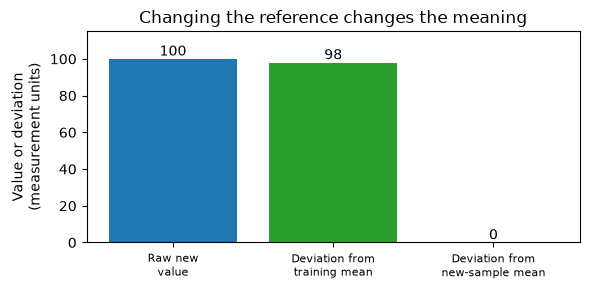

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, ax = plt.subplots(figsize=(6, 3))
labels = ['Raw new\nvalue', 'Deviation from\ntraining mean', 'Deviation from\nnew-sample mean']
values = [100, 98, 0]
bars = ax.bar(labels, values, color=['tab:blue', 'tab:green', 'tab:red'])
ax.bar_label(bars)
ax.set(ylabel='Value or deviation\n(measurement units)', title='Changing the reference changes the meaning', ylim=(0, 115))
ax.tick_params(axis='x', labelsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

The zero is not evidence that the new observation is ordinary relative to training data. It is zero only relative to a reference calculated from itself. Raw values and deviations also have different reference points despite sharing units. The labels make that distinction explicit.

## 11. Enclosing scope and a useful failure

In [6]:
def make_centerer(mean):
    def transform(value):
        return value - mean
    return transform

closure_center = make_centerer(2.0)
assert closure_center(100.0) == 98

counter = 5
def broken_increment():
    counter = counter + 1
    return counter

try:
    broken_increment()
except UnboundLocalError as error:
    print('Expected local-name failure:', type(error).__name__)
else:
    raise AssertionError('The expected scope error did not occur')
assert counter == 5

Expected local-name failure: UnboundLocalError


The nested transform reads an enclosing mean. In `broken_increment`, assignment makes counter local throughout the function, so the right side tries to read a local value before one exists. Adding `global` would permit mutation of the outer counter, but an explicit input/output function is usually clearer for a calculation.

## 12. Configuration choices

Choose explicit arguments for changing inputs, local variables for intermediates, and documented configuration for fitted settings. There are no learned prediction parameters here; the example mean is a fitted descriptive statistic. Closures can capture mutable objects too, so they do not automatically eliminate state. A function reading a global constant can be acceptable when the dependency is intentional and stable, but avoid hidden mutable experimental configuration.

## 13. Evaluation

Test the same explicit call after unrelated top-level assignments. Restart and run all cells to verify that no unrecorded global is required. For the centering rule, check that training deviations sum to zero within numerical tolerance and that new data do not alter the stored training reference. Keep configuration with its provenance rather than relying on a variable name to prove where it came from.

In [7]:
training_deviations = [trained_center(value) for value in training_values]
assert sum(training_deviations) == 0
before = dict(trained_center.keywords)
new_deviation = trained_center(200.0)
assert new_deviation == 198 and trained_center.keywords == before

## 14. Assumptions and limitations

LEGB describes common function name lookup, but Python also has rules for classes, comprehensions, and other constructs. This lesson focuses on ordinary functions and notebook/module globals. Explicit arguments improve auditability but cannot prove the caller supplied an appropriate training statistic. Correct information flow is a property of the entire experiment.

## 15. Common mistakes and debugging

Do not fix every name error by declaring a global. Do not assume a function freezes all values visible when it is defined. Avoid shadowing built-ins such as `list` or `sum`. Print explicit configuration and arguments when a result changes unexpectedly. Restart the kernel after exploring state changes rather than trying to remember which of many cells ran last.

## 16. Comparison with alternatives

Explicit function arguments are simple and testable. A partial or closure stores a small configuration for reuse. A class can manage a larger fitted state with clear methods. A module can hold stable constants. Select the smallest structure that makes the actual dependencies visible; adding layers does not by itself remove hidden state.

## 17. Exercises

1. **Beginner:** Identify the scope of a function argument, a top-level assignment, and the built-in `len`.
2. **Beginner:** Center a new value nine using training values two and four, by hand.
3. **Beginner:** Explain why `center_hidden(100)` changed when its visible argument did not.
4. **Intermediate:** Rewrite a counter update as a pure function that receives the old count and returns the new one.
5. **Intermediate:** Explain how a mutable object captured by a closure can still change future results.
6. **Challenge:** Build a configured centering callable from a copy of training values, reject empty or nonfinite inputs, and verify that editing the original training list afterward does not change its reference.

## 18. Detailed solutions

1. The argument is local, the top-level name global, and `len` normally resolves from built-ins unless shadowed.
2. The training mean is three, so the new deviation is six in the original measurement units.
3. Its body read a global reference at call time; that reference had been rebound from two to 100.
4. `def increment(old): return old + 1` has explicit information flow and does not require global mutation.
5. A closure holding a list can read its later changed contents. Capturing a reference is not recursively freezing the object.
6. Compute and retain a validated scalar mean rather than a reference to a mutable source list. The code uses the explicit centering function already defined.

In [8]:
import math

def fitted_centerer(training):
    snapshot = tuple(training)
    if not snapshot or any(type(value) not in (int, float) or not math.isfinite(value) for value in snapshot):
        raise ValueError('Training values must be nonempty finite ordinary numbers')
    mean = math.fsum(snapshot) / len(snapshot)
    return partial(center_explicit, mean=mean)

source = [2.0, 4.0]
configured = fitted_centerer(source)
source[0] = 1000.0
assert configured(9.0) == 6
assert configured.keywords['mean'] == 3
for bad in ([], [float('nan')]):
    try:
        fitted_centerer(bad)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid training input accepted')
print('Independent fitted reference:', configured.keywords)

Independent fitted reference: {'mean': 3.0}


## 19. Knowledge check

**What does LEGB summarize?** Common name lookup from narrow to broad scopes. **When is a global normally read?** When the function executes the lookup. **What is shadowing?** A narrower binding hides a broader name. **Does a closure guarantee immutability?** No. **Why store preprocessing configuration?** To apply the intended training-derived rule consistently.

## 20. Interview preparation

**Why can a notebook pass only in one cell order?** Hidden state supplies dependencies not recreated by the document's ordinary sequence. **Why can assignment cause UnboundLocalError?** The name is local but read before local initialization. **Explicit arguments versus globals?** Explicit inputs improve tracing and isolation; stable documented globals can still be intentional. **What can a closure retain?** Access to enclosing bindings and referenced objects. **How does scope relate to leakage?** Hidden mutable settings can accidentally be replaced by evaluation-derived information, changing the experimental procedure.

## 21. Summary and next steps

Names have locations as well as values. Keep numerical dependencies explicit and fitted statistics tied to training information. Continue to [List comprehensions](../../../01_Python_Foundations/08_list_comprehensions.ipynb) for concise transformations whose filtering and shapes still need inspection.